# <font color='green'>Interactive introduction to lattice surgery</font>

In [1]:
# %load_ext autoreload
# %autoreload 2
%matplotlib widget

In the last chapter, we saw two popular alternatives to implement logical operations. transversal logic vs. lattice surgery. 
Lattice surgery is beneficial, particularly when qubits are not directly connected over long ranges $^1$.  
In this chapter, we will first see the effect of pauli Z and X errors on a rotated surface code patch in an interactive way and learn about how performing a $Z \otimes Z$ measurement between two surface code patches via lattice surgery. 


# <font color='green'>Quick brush up on surface codes</font>

In Chapter 4, we saw the layout of a planar unrotated surface code. In many practical applications, the rotated surface code is used due to its resource efficiency $^2$. 

A rotated surface code of distance $d$ encodes one logical qubit and has parameters $[[n= d^2, k=1, d]]$ (for odd $d$). The code is defined by a stabilizer group $\mathcal{S}$ generated by:

- $X$-type plaquette operators: $S_p^X = \prod_{i \in p} X_i$
- $Z$-type plaquette operators: $S_p^Z = \prod_{i \in p} Z_i$

where each stabilizer acts on 4 neighboring data qubits (except at boundaries).

In [2]:
from latticesurgeryprimitives import (
    Patch, SurgerySession,
    apply_error, measure_stab, logical_ZZ_eigenvalue
)

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Wedge


Here, we create a distance $d=5$ rotated surface code patch. Blue plaquettes are $Z$ stabilizers ($Z \otimes Z \otimes Z \otimes Z$), and red plaquettes are $X$ stabilizers ($X \otimes X \otimes X \otimes X$). One can play around and apply $X$ and $Z$ errors to the data qubits by toggling between $x$ and $z$ keys. 

An $X$ error anticommutes with neighboring $Z$-type stabilizers. If $S_p^Z$ is a $Z$ stabilizer adjacent to the qubit where a bit flip has occurred, then:

$$
S_p^Z X_i = - X_i S_p^Z
$$

Thus, the measurement outcome of $S_p^Z$ flips from $+1$ to $-1$, allowing us to detect where an error has occurred.

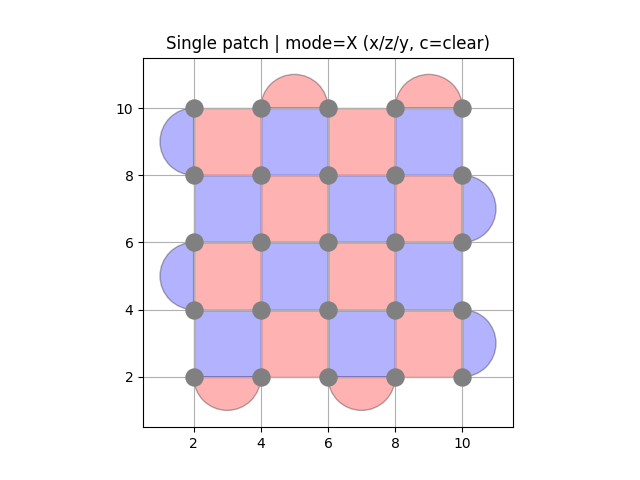

In [8]:
d = 5
offset = 2

patch = Patch("q", d, offset, place=(0,0), mirror_z=False)

current_op = "X"

def add_boundary_wedge(ax, sx, sz, min_gx, max_gx, min_gz, max_gz, color, alpha):
    r = 1
    if sx < min_gx:
        center = (sx + 1, sz); theta1, theta2 = 90, 270
    elif sx > max_gx:
        center = (sx - 1, sz); theta1, theta2 = 270, 90
    elif sz < min_gz:
        center = (sx, sz + 1); theta1, theta2 = 180, 360
    elif sz > max_gz:
        center = (sx, sz - 1); theta1, theta2 = 0, 180
    else:
        return
    ax.add_patch(Wedge(center, r, theta1, theta2, facecolor=color, edgecolor="black", alpha=alpha))

fig = plt.figure()

def draw_one():
    fig.clf()
    ax = fig.gca()

    err_u = dict(patch.error)

    min_gx = min(x for (x,z) in patch.data_global)
    max_gx = max(x for (x,z) in patch.data_global)
    min_gz = min(z for (x,z) in patch.data_global)
    max_gz = max(z for (x,z) in patch.data_global)

    for sid, stab in patch.stabs_local.items():
        if sid not in patch.active_stabs:
            continue
        sx, sz, kind, neigh_g, w = patch.stab_global(stab)
        res = measure_stab(kind, neigh_g, err_u)
        color = "blue" if kind == "Z" else "red"
        alpha = 0.8 if res == 1 else 0.3

        if w == 4:
            ax.add_patch(Rectangle((sx-1, sz-1), 2, 2, facecolor=color, edgecolor="black", alpha=alpha))
        else:
            add_boundary_wedge(ax, sx, sz, min_gx, max_gx, min_gz, max_gz, color, alpha)

    for coord, err in err_u.items():
        ax.scatter(coord[0], coord[1], color="grey", s=150, zorder=3)
        if err != "I":
            ax.text(coord[0], coord[1], err, ha="center", va="center", zorder=4)

    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_title(f"Single patch | mode={current_op} (x/z/y, c=clear)")
    fig.canvas.draw_idle()

def on_click(event):
    global current_op
    if event.xdata is None or event.ydata is None:
        return
    coord = (round(event.xdata), round(event.ydata))
    if coord not in patch.error:
        return
    if current_op == "I":
        patch.error[coord] = "I"
    else:
        apply_error(coord, current_op, patch.error)
    draw_one()

def on_key(event):
    global current_op
    k = event.key
    if k == "x": current_op = "X"
    elif k == "z": current_op = "Z"
    elif k == "y": current_op = "Y"
    elif k in ("c","backspace","delete"): current_op = "I"
    draw_one()

fig.canvas.mpl_connect("button_press_event", on_click)
fig.canvas.mpl_connect("key_press_event", on_key)

draw_one()
plt.show()


One can similarly apply $Z$ errors to the data qubits and detect them with the $X$ stabilizers. 
Quick check: 
A logical operator corresponds to a string of Pauli operators that commutes with all stabilizers but is not itself in the stabilizer group. For example, a vertical string of $X$ operators implements the logical operator $\bar{X}$:

$$
\bar{X} = \prod_{i \in \text{vertical path}} X_i
$$

Such an operator connects two opposing boundaries.

# <font color='green'>Lattice surgery</font>

Now that we have our surface code patch, we want to do meaningful logical operations between two patches. 
Lattice surgery gives us a way to perform multiqubit joint Pauli measurements between surface code patches. 
Here we will see how to perform a $Z \otimes Z$ measurement between two surface code patches. 




Lattice surgery is based on two techniques: merging and splitting. 

In the rotated surface code above, the logical $Z$ operator is along the horizontal direction. We place the second patch below the first patch such that its $Z$ boundary (or rough boundary) faces the first patch's $Z$ boundary. 
In the merge step, we merge the two lattices by creating new weight 4 $Z$ stabilizers between them to create a larger $2d \times d$ lattice, while merging, one measures the newly created $Z$ stabilizers, and the product of the outcomes of all the $Z$ stabilizers corresponds to the outcome of the logical joint operator $\bar Z_1 \bar Z_2$.. 
But any subset of these outcomes produces a random result when multiplied together. 

To recover the original codespace, the lattice is split back to its original state.
After splitting, some boundary $X$-stabilizers can pick up random signs, but the signs are correlated and can be corrected.
The $Z$ measurements do not commute with the 2-body $X$ stabilizers at the merge boundary. 
Therefore, after measurement, the stabilizer group must be updated by keeping only commuting elements, as prescribed by the stabilizer measurement update rules (Gottesman–Knill theorem).

In the code block below, one can see the merge and split steps in action by toggling between 'm' (merge) and 'p' (split) keys. 
One can experiment by adding errors and see how the final measurement outcome is shown at the top of the figure.   

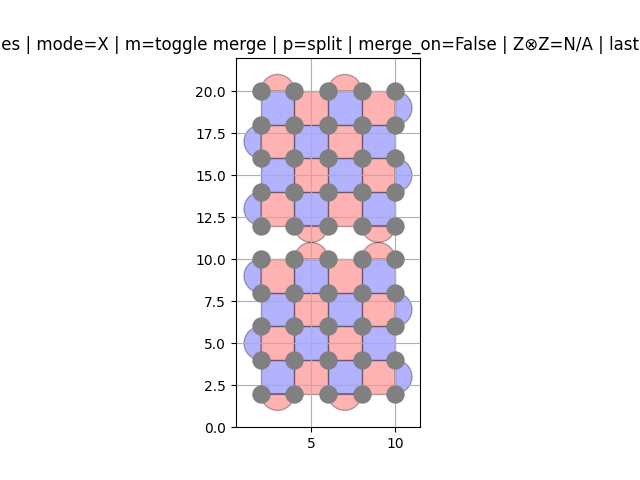

In [ ]:
# --- build two patches ---
d = 5
offset = 2
gap = 2

q = Patch("q", d, offset, place=(0,0), mirror_z=False)

q_max_gz = max(z for (x,z) in q.data_global)
p_place_z = (q_max_gz + gap) - offset
p = Patch("p", d, offset, place=(0, p_place_z), mirror_z=True)

session = SurgerySession(q, p, gap=gap)

current_op = "X"
last_ZZ = None

def record_ZZ():
    global last_ZZ
    zz = logical_ZZ_eigenvalue(session)
    if zz is not None:
        last_ZZ = zz

def add_boundary_wedge(ax, sx, sz, min_gx, max_gx, min_gz, max_gz, color, alpha):
    r = 1
    if sx < min_gx:
        center = (sx + 1, sz); theta1, theta2 = 90, 270
    elif sx > max_gx:
        center = (sx - 1, sz); theta1, theta2 = 270, 90
    elif sz < min_gz:
        center = (sx, sz + 1); theta1, theta2 = 180, 360
    elif sz > max_gz:
        center = (sx, sz - 1); theta1, theta2 = 0, 180
    else:
        return
    ax.add_patch(Wedge(center, r, theta1, theta2, facecolor=color, edgecolor="black", alpha=alpha))

fig = plt.figure()

def draw_two():
    fig.clf()
    ax = fig.gca()
    err_u = session.error_union()

    def draw_patch(patch):
        min_gx = min(x for (x,z) in patch.data_global)
        max_gx = max(x for (x,z) in patch.data_global)
        min_gz = min(z for (x,z) in patch.data_global)
        max_gz = max(z for (x,z) in patch.data_global)

        for sid, stab in patch.stabs_local.items():
            if sid not in patch.active_stabs:
                continue
            sx, sz, kind, neigh_g, w = patch.stab_global(stab)
            res = measure_stab(kind, neigh_g, err_u)
            color = "blue" if kind == "Z" else "red"
            alpha = 0.8 if res == 1 else 0.3

            if w == 4:
                ax.add_patch(Rectangle((sx-1, sz-1), 2, 2, facecolor=color, edgecolor="black", alpha=alpha))
            elif w == 2:
                add_boundary_wedge(ax, sx, sz, min_gx, max_gx, min_gz, max_gz, color, alpha)

    draw_patch(q)
    draw_patch(p)

    if session.merge_on:
        data_union = q.data_global_set | p.data_global_set
        min_gx = min(x for (x,z) in data_union)
        max_gx = max(x for (x,z) in data_union)
        min_gz = min(z for (x,z) in data_union)
        max_gz = max(z for (x,z) in data_union)

        for _, stab in session.seam_stabs.items():
            sx, sz = stab["coord"]
            kind = stab["kind"]
            w = len(stab["neighbors"])
            res = measure_stab(kind, stab["neighbors"], err_u)

            # seam Z checks shown as blue; seam X checks as red
            color = "blue" if kind == "Z" else "red"
            if kind == "Z":
                ax.text(sx, sz, "±", ha="center", va="center", color="black", )
                alpha = 0.85 if res == 1 else 0.45
            else:
                alpha = 0.85 if res == 1 else 0.35

            if w == 4:
                ax.add_patch(Rectangle((sx-1, sz-1), 2, 2, facecolor=color, edgecolor="black", alpha=alpha))
            elif w == 2:
                add_boundary_wedge(ax, sx, sz, min_gx, max_gx, min_gz, max_gz, color, alpha)

    for coord, err in err_u.items():
        ax.scatter(coord[0], coord[1], color="grey", s=150, zorder=3)
        if err != "I":
            ax.text(coord[0], coord[1], err, ha="center", va="center", zorder=4)

    zz = logical_ZZ_eigenvalue(session)
    zz_txt = "N/A" if zz is None else ("+1" if zz == 1 else "-1")
    last_txt = "None" if last_ZZ is None else ("+1" if last_ZZ == 1 else "-1")

    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_title(
        f"Two patches | mode={current_op} | m=toggle merge | p=split | "
        f"merge_on={session.merge_on} | Z⊗Z={zz_txt} | last Z⊗Z={last_txt}"
    )
    fig.canvas.draw_idle()

def which_patch(coord):
    if coord in q.error: return q
    if coord in p.error: return p
    return None

def on_click(event):
    global current_op
    if event.xdata is None or event.ydata is None:
        return
    coord = (round(event.xdata), round(event.ydata))
    patch = which_patch(coord)
    if patch is None:
        return
    if current_op == "I":
        patch.error[coord] = "I"
    else:
        apply_error(coord, current_op, patch.error)
    draw_two()

def on_key(event):
    global current_op, last_ZZ
    k = event.key
    if k == "x": current_op = "X"
    elif k == "z": current_op = "Z"
    elif k == "y": current_op = "Y"
    elif k in ("c","backspace","delete"): current_op = "I"
    elif k == "m":
        if session.merge_on:
            record_ZZ()
        session.toggle_merge()
    elif k == "p":
        if session.merge_on:
            record_ZZ()
            session.toggle_merge()
    elif k == "t":
        # logical X on q: x=2, z=2..6 (global)
        for z in (2,4,6):
            apply_error((2, z), "X", q.error)

    draw_two()

fig.canvas.mpl_connect("button_press_event", on_click)
fig.canvas.mpl_connect("key_press_event", on_key)

draw_two()
plt.show()


$^1$[A Game of Surface Codes: Large-Scale Quantum Computing with Lattice Surgery](https://arxiv.org/abs/1808.02892)

$^2$[Compare the Pair: Rotated vs. Unrotated Surface Codes at Equal Logical Error Rates](https://arxiv.org/abs/2409.14765)



---
### Version History
- v0: Dec 8, 2025, [github/@Next-di-mension](https:github.com/Next-di-mension)